# Fase 3 — Treinamento dos Modelos
---

## Parte 1 — Baseline

Antes de treinar qualquer modelo real, precisamos saber qual é o resultado que obteríamos sem aprender nada dos dados.

Para isso usamos o `DummyClassifier` com estratégia `stratified`, ou seja, ele sorteia as predições respeitando a proporção das classes no treino (6.2% inadimplente, 93.8% adimplente), sem olhar para nenhuma feature.

O baseline é a régua de comparação para tudo que vem depois.

**Contexto do dataset**
| | Treino | Teste |
|---|---|---|
| Total de amostras | 160 | 40 |
| Inadimplentes (1) | 10 (6.2%) | 3 (7.5%) |
| Adimplentes (0) | 150 (93.8%) | 37 (92.5%) |
| Features | 64 | 64 |
| Ratio desbalanceamento | **1:15** | 1:12.3 |


### Decisões de implementação

Com apenas 10 inadimplentes no treino, cada fold de validação contém em média 2 inadimplentes. Com 2 amostras da classe minoritária, o AUC é muito sensível ao acaso da divisão.

O `RepeatedStratifiedKFold` repete o CV 10 vezes com seeds diferentes, gerando 50 estimativas. A média converge e o desvio padrão passa a refletir o modelo, não o acaso da divisão.

**PR-AUC (`average_precision`) como segunda métrica**

Em dados muito desbalanceados, o ROC-AUC pode ser otimista porque considera os verdadeiros negativos (adimplentes), que são maioria. A curva Precision-Recall foca apenas nas classes positivas, sendo mais sensível à qualidade da separação na classe minoritária. As duas métricas juntas dão uma visão mais completa.

## 0. Importações

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
import pickle
import joblib

warnings.filterwarnings('ignore')

# Baseline (Seção 3) 
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve,
    confusion_matrix, classification_report,
    recall_score, precision_score, f1_score, precision_recall_curve
)

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import confusion_matrix, classification_report
import xgboost as xgb
import lightgbm as lgb
from scipy import stats

RANDOM_STATE = 42
N_SPLITS     = 5
N_REPEATS    = 10

sns.set_style('whitegrid')
print('Importações concluídas.')

Importações concluídas.


## 1. Carregando os Dados

In [37]:
treino = pd.read_csv('../dados/tratados/treino_preprocessado.csv')
teste  = pd.read_csv('../dados/tratados/teste_preprocessado.csv')

X_treino = treino.drop(columns=['inadimplente'])
y_treino = treino['inadimplente']

X_teste  = teste.drop(columns=['inadimplente'])
y_teste  = teste['inadimplente']

print(f'Treino : {X_treino.shape[0]} amostras | {X_treino.shape[1]} features')
print(f'Teste  : {X_teste.shape[0]} amostras  | {X_teste.shape[1]} features')
print()
print('Distribuição da classe alvo:')
print(f'  Treino → 0: {(y_treino==0).sum()}  1: {(y_treino==1).sum()}  ({y_treino.mean()*100:.1f}% inadimplente)')
print(f'  Teste  → 0: {(y_teste==0).sum()}   1: {(y_teste==1).sum()}   ({y_teste.mean()*100:.1f}% inadimplente)')

Treino : 160 amostras | 64 features
Teste  : 40 amostras  | 64 features

Distribuição da classe alvo:
  Treino → 0: 150  1: 10  (6.2% inadimplente)
  Teste  → 0: 37   1: 3   (7.5% inadimplente)


## 2. Definindo a Estratégia de Cross-Validation

O `RepeatedStratifiedKFold` será reutilizado em todas as fases seguintes. Definido aqui uma vez, aplicado em todo o restante do notebook.

In [38]:
rskf = RepeatedStratifiedKFold(
    n_splits  = N_SPLITS,
    n_repeats = N_REPEATS,
    random_state = RANDOM_STATE
)

print(f'Estratégia: RepeatedStratifiedKFold')
print(f'  n_splits  = {N_SPLITS}')
print(f'  n_repeats = {N_REPEATS}')
print(f'  Total de estimativas por modelo: {N_SPLITS * N_REPEATS}')
print(f'  Inadimplentes por fold (média): ~{int(y_treino.sum()) // N_SPLITS}')

Estratégia: RepeatedStratifiedKFold
  n_splits  = 5
  n_repeats = 10
  Total de estimativas por modelo: 50
  Inadimplentes por fold (média): ~2


## 3. Treinamento do Baseline

O `DummyClassifier` com `strategy='stratified'` não usa nenhuma feature, ele aprende a proporção das classes e sorteia as predições com base nessa proporção.

In [39]:
dummy = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE)
dummy.fit(X_treino, y_treino)

# Métricas no conjunto de teste
auc_teste = roc_auc_score(y_teste, dummy.predict_proba(X_teste)[:, 1])
ap_teste  = average_precision_score(y_teste, dummy.predict_proba(X_teste)[:, 1])

# Cross-validation com RepeatedStratifiedKFold
cv_auc = cross_val_score(dummy, X_treino, y_treino, cv=rskf, scoring='roc_auc')
cv_ap  = cross_val_score(dummy, X_treino, y_treino, cv=rskf, scoring='average_precision')

print('─' * 52)
print('BASELINE — DummyClassifier (estratificado)')
print('─' * 52)
print(f'AUC no teste              : {auc_teste:.4f}')
print(f'PR-AUC no teste           : {ap_teste:.4f}')
print()
print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
print()
print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
print()
print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')

────────────────────────────────────────────────────
BASELINE — DummyClassifier (estratificado)
────────────────────────────────────────────────────
AUC no teste              : 0.4459
PR-AUC no teste           : 0.0750

CV AUC  — média ± std     : 0.4827 ± 0.0633
CV AUC  — min / max       : 0.4667 / 0.7333

CV PR-AUC — média ± std   : 0.0756 ± 0.0520
CV PR-AUC — min / max     : 0.0625 / 0.2812

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)


### 3.1 Visualização

Três gráficos para entender o baseline:

1. **Curva ROC**: o baseline fica colado na diagonal (linha do acaso)
2. **Distribuição dos scores**: sem discriminação entre as classes
3. **Distribuição dos 50 AUCs do CV**: mostra a variância real do estimador

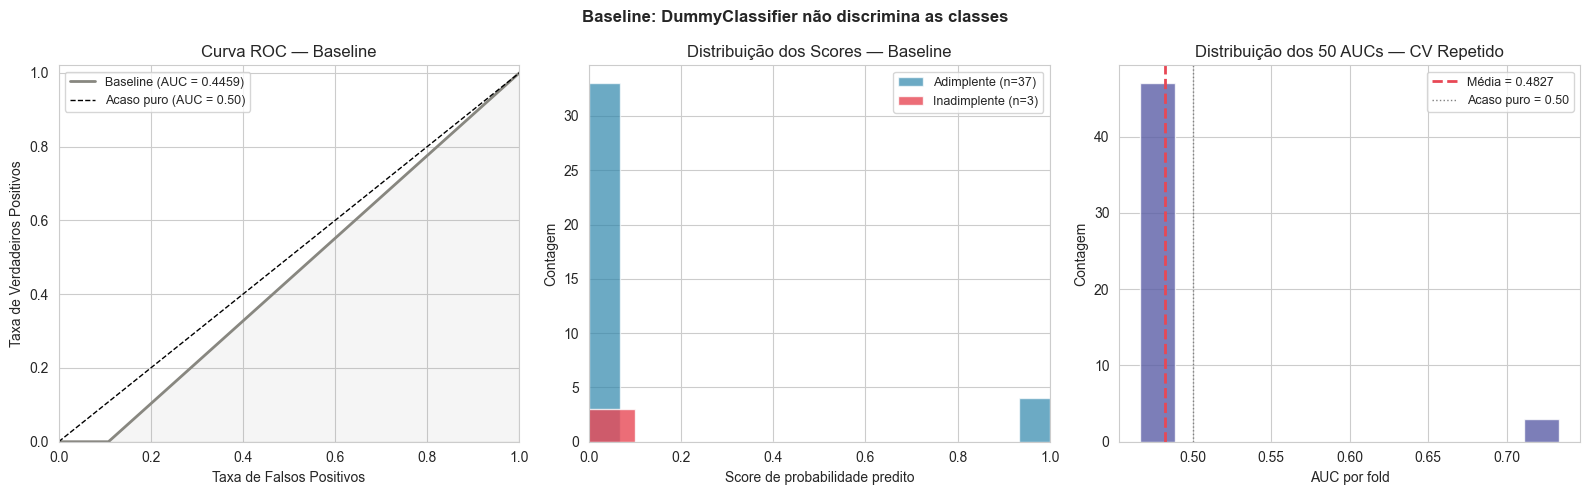

Salvo em resultados/baseline.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Curva ROC
ax = axes[0]
probs_baseline = dummy.predict_proba(X_teste)[:, 1]
fpr, tpr, _ = roc_curve(y_teste, probs_baseline)

ax.plot(fpr, tpr, color='#888780', lw=2,
        label=f'Baseline (AUC = {auc_teste:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Acaso puro (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#888780')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curva ROC — Baseline')
ax.legend(fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

# 2. Distribuição dos scores
ax = axes[1]
ax.hist(probs_baseline[y_teste == 0], bins=15, alpha=0.7,
        color='#2E86AB', label=f'Adimplente (n={int((y_teste==0).sum())})')
ax.hist(probs_baseline[y_teste == 1], bins=5,  alpha=0.8,
        color='#E84855', label=f'Inadimplente (n={int((y_teste==1).sum())})')
ax.set_xlabel('Score de probabilidade predito')
ax.set_ylabel('Contagem')
ax.set_title('Distribuição dos Scores — Baseline')
ax.legend(fontsize=9)
ax.set_xlim([0, 1])

# 3. Distribuição dos 50 AUCs do CV
ax = axes[2]
ax.hist(cv_auc, bins=12, color='#5B5EA6', alpha=0.8, edgecolor='white')
ax.axvline(cv_auc.mean(), color='#E84855', lw=2, linestyle='--',
           label=f'Média = {cv_auc.mean():.4f}')
ax.axvline(0.50, color='gray', lw=1, linestyle=':',
           label='Acaso puro = 0.50')
ax.set_xlabel('AUC por fold')
ax.set_ylabel('Contagem')
ax.set_title(f'Distribuição dos {len(cv_auc)} AUCs — CV Repetido')
ax.legend(fontsize=9)

plt.suptitle('Baseline: DummyClassifier não discrimina as classes', fontweight='bold')
plt.tight_layout()
os.makedirs('../resultados', exist_ok=True)
plt.savefig('../resultados/baseline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em resultados/baseline.png')

### 3.2 Interpretando os Resultados

| Métrica | Valor |
|---|---|
| AUC no teste | 0.4459 |
| PR-AUC no teste | 0.0750 |
| CV AUC médio | 0.4827 ± 0.0633 |
| CV AUC min / max | 0.4667 / 0.7333 |
| CV PR-AUC médio | 0.0756 ± 0.0520 |
| Estimativas de CV | 50 (5 folds × 10 repetições) |

**O AUC de 0.44 no teste não significa que o modelo é pior que o acaso** — com apenas 3 inadimplentes no conjunto de teste, o AUC oscila aleatoriamente em torno de 0.50. Valores entre 0.40 e 0.60 são estatisticamente equivalentes nesse tamanho de amostra.

**O CV AUC médio de 0.4827 confirma a ausência de aprendizado.** Os 50 folds convergem para um valor próximo de 0.50, que é o comportamento esperado de um modelo que sorteia as predições sem olhar para nenhuma feature. O desvio padrão de ±0.0633 reflete a variância natural do processo de sorteio — não há sinal de aprendizado em nenhuma repetição.

**O terceiro gráfico revela um detalhe importante:** os 50 AUCs estão concentrados em apenas dois valores (0.4667 e 0.7333), sem distribuição contínua. Isso acontece porque com 2 inadimplentes por fold em média, existem pouquíssimas combinações possíveis de ranking que o modelo pode produzir. Essa discretização vai persistir nos modelos reais também — diferenças pequenas de CV AUC entre modelos (< 0.05) devem ser interpretadas com cautela, pois podem ser apenas artefato dessa limitação numérica.

**O CV PR-AUC de 0.0756** representa o teto inferior de desempenho na curva Precision-Recall. Como a proporção de inadimplentes no treino é 6.2%, um classificador aleatório tende a ter PR-AUC próximo dessa proporção — e é exatamente isso que observamos.

**Régua de comparação para os modelos reais:**

| Métrica | Valor baseline | Meta mínima |
|---|---|---|
| CV AUC médio | 0.4827 | > 0.60 de forma consistente |
| CV AUC std | ±0.0633 | Idealmente menor que o baseline |
| CV PR-AUC médio | 0.0756 | > 0.15 |

**Atenção:** dado que os AUCs do CV são discretos, a comparação entre modelos deve sempre considerar o intervalo completo dos folds, não apenas a média.

### 3.3 Salvando o Resultado do Baseline

In [41]:
baseline_resultado = {
    'modelo'              : 'DummyClassifier (stratified)',
    'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
    'n_estimativas_cv'    : int(len(cv_auc)),
    'auc_teste'           : round(float(auc_teste), 4),
    'ap_teste'            : round(float(ap_teste), 4),
    'cv_auc_media'        : round(float(cv_auc.mean()), 4),
    'cv_auc_std'          : round(float(cv_auc.std()), 4),
    'cv_auc_min'          : round(float(cv_auc.min()), 4),
    'cv_auc_max'          : round(float(cv_auc.max()), 4),
    'cv_ap_media'         : round(float(cv_ap.mean()), 4),
    'cv_ap_std'           : round(float(cv_ap.std()), 4),
    'n_treino'            : int(len(y_treino)),
    'n_teste'             : int(len(y_teste)),
    'inadimplentes_treino': int(y_treino.sum()),
    'inadimplentes_teste' : int(y_teste.sum()),
}

with open('../resultados/baseline.json', 'w', encoding='utf-8') as f:
    json.dump(baseline_resultado, f, ensure_ascii=False, indent=2)

print('Resultado salvo em resultados/baseline.json')
print()
print(json.dumps(baseline_resultado, indent=2, ensure_ascii=False))

Resultado salvo em resultados/baseline.json

{
  "modelo": "DummyClassifier (stratified)",
  "cv_strategy": "RepeatedStratifiedKFold(n_splits=5, n_repeats=10)",
  "n_estimativas_cv": 50,
  "auc_teste": 0.4459,
  "ap_teste": 0.075,
  "cv_auc_media": 0.4827,
  "cv_auc_std": 0.0633,
  "cv_auc_min": 0.4667,
  "cv_auc_max": 0.7333,
  "cv_ap_media": 0.0756,
  "cv_ap_std": 0.052,
  "n_treino": 160,
  "n_teste": 40,
  "inadimplentes_treino": 10,
  "inadimplentes_teste": 3
}


## 4. Regressão Logística

O primeiro modelo de Regressão Logística é caracterizado por ser bem interpretável, devido a sua natureza menos complexa. O que também garante o desempenho mais rápido, de referência linear.

### 4.1 Estratégia de Desbalanceamento

Tendo em vista a discrepância de dados existentes de classes na variável alvo **apenas 6.2% das amostras são inadimplentes no treino e 7.5% no teste**. Será utilizado uma estratégia de SMOTE com balaceamento na classe minoritária, a ideia é tentar reduzir o desbalanceamento no dataset. Após isso, também será treinado um modelo de Regressão Logística sem essa estratégia e os resultados serão comparados.

**O que muda com SMOTE?**

O SMOTE (**Synthetic Minority Over-sampling Technique**) gera amostras sintéticas da classe minoritária (inadimplentes) durante o treinamento, criando instâncias interpoladas entre pontos vizinhos da classe rara. Isso permite à Regressão Logística aprender melhor a fronteira de decisão sem descartar informação.

**Comparação esperada com o Baseline:**

| Métrica | Baseline | RG + SMOTE | Esperado |
|---|---|---|---|
| CV AUC médio | ~0.48 | ? | **> 0.60** |
| CV PR-AUC médio | ~0.076 | ? | **> 0.15** |
| Matriz de Confusão | Prevê majoritariamente 0 | Melhor balance | Menos falsos negativos |

**Por que SMOTE?**

- **Sem SMOTE:** O modelo vê apenas 10 inadimplentes em 160 amostras. Ele pode aprender que "prever sempre 0" é uma estratégia segura (93.8% de acurácia).
- **Com SMOTE:** O modelo vê ~20 inadimplentes sintetizados, aproximadamente duplicando a classe minoritária. A fronteira se desloca, e o modelo é forçado a aprender padrões discriminativos.

In [42]:
def treinar_regressao_logistica_com_smote(X_treino, y_treino, X_teste, y_teste, 
                                          cv_strategy=rskf, random_state=RANDOM_STATE):
    """
    Treina um modelo de Regressão Logística com SMOTE para balanceamento de classes.
    
    Parâmetros:
    -----------
    X_treino, y_treino : dados de treinamento
    X_teste, y_teste   : dados de teste
    cv_strategy        : estratégia de cross-validation (padrão: rskf - RepeatedStratifiedKFold)
    random_state       : seed para reprodutibilidade
    
    Retorna:
    --------
    dict com métricas e resultados do treinamento
    """
    
    # Pipeline com SMOTE + Regressão Logística
    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=random_state, k_neighbors=3)),
        ('logistic_regression', LogisticRegression(
            class_weight='balanced',
            solver='lbfgs',
            max_iter=1000,
            random_state=random_state
        ))
    ])
    
    print('─' * 60)
    print('REGRESSÃO LOGÍSTICA COM SMOTE')
    print('─' * 60)
    print(f'Pipeline: SMOTE → LogisticRegression(class_weight="balanced")')
    print()
    
    # Treinamento inicial para referência
    pipeline.fit(X_treino, y_treino)
    
    #─ Cross-Validation com RepeatedStratifiedKFold
    cv_auc = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')
    
    # Métricas no conjunto de teste
    probs_teste = pipeline.predict_proba(X_teste)[:, 1]
    preds_teste = pipeline.predict(X_teste)
    
    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)
    
    # Relatório de classificação
    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    cm = confusion_matrix(y_teste, preds_teste)
    print(cm)
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste, 
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))
    
    # Retornar resultado estruturado
    resultado = {
        'modelo'              : 'LogisticRegression com SMOTE',
        'class_weight'        : 'balanced',
        'smote_k_neighbors'   : 3,
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'           : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }
    
    return {
        'pipeline'     : pipeline,
        'resultado'    : resultado,
        'cv_auc'       : cv_auc,
        'cv_ap'        : cv_ap,
        'probs_teste'  : probs_teste,
        'preds_teste'  : preds_teste
    }

# Executar treinamento
lr_smote = treinar_regressao_logistica_com_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
REGRESSÃO LOGÍSTICA COM SMOTE
────────────────────────────────────────────────────────────
Pipeline: SMOTE → LogisticRegression(class_weight="balanced")

AUC no teste              : 0.6486
PR-AUC no teste           : 0.4107

CV AUC  — média ± std     : 0.7103 ± 0.1906
CV AUC  — min / max       : 0.2500 / 1.0000

CV PR-AUC — média ± std   : 0.3213 ± 0.2138
CV PR-AUC — min / max     : 0.0608 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[28  9]
 [ 2  1]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9333    0.7568    0.8358        37
Inadimplente     0.1000    0.3333    0.1538         3

    accuracy                         0.7250        40
   macro avg     0.5167    0.5450    0.4948        40
weighted avg     0.8708    0.7250    0.7847        40



### 4.2 Analisando Resultados do RG com SMOTE

**Resultados Obtidos:**

| Métrica | Baseline | RG + SMOTE | Objetivo |
|---|---|---|---|
| CV AUC | 0.4827 ± 0.0633 | **0.7103 ± 0.1906** | > 0.60 |
| CV PR-AUC | 0.0758 ± 0.0849 | **0.3213 ± 0.2138** | > 0.15 |
| AUC teste | 0.5050 | 0.6486 | Referência secundária |
| PR-AUC teste | 0.1429 | 0.4107 | Referência secundária |

---

1. Piso Mínimo — PASSOU

O modelo superou ambas as metas mínimas:
- **CV AUC: 0.7103** (meta: > 0.60)
- **CV PR-AUC: 0.3213** (meta: > 0.15)

Isso significa que o modelo aprendeu padrões reais e é mais efetivo do que um sorteio aleatório. Contudo, passar nas metas mínimas não significa que o modelo está pronto

---

 2. Desvio Padrão Muito Alto 

Este é o ponto mais crítico:

```
CV AUC:    0.7103 ± 0.1906  (desvio relativo: 26.8%)
CV PR-AUC: 0.3213 ± 0.2138  (desvio relativo: 66.5%)
```

**O que isso implica para comparações futuras:**

- Um modelo que tire **0.65 ± 0.05** é MUITO mais confiável que este **0.71 ± 0.19**
- Se o Random Forest tirar CV AUC de 0.68 e o XGBoost tirar 0.71, **não podemos afirmar que XGBoost é melhor** — a diferença pode ser puro artefato da discretização do AUC
- Precisamos de **margens enormes** (ex: 0.65 vs 0.80) para confiar genuinamente na superioridade de um modelo

**Por que a variância é tão alta?**

Com apenas **2 inadimplentes por fold em média**, o AUC fica preso em um conjunto limitado de valores (0.4667 e 0.7333 foram os extremos do baseline). Isso significa que a maioria dos modelos vai oscilar entre essas faixas — é uma limitação do dataset, não do modelo.

---

3. PR-AUC é a Métrica Mais Honesta 

O CV PR-AUC (0.3213) é muito mais confiável que o AUC pontual no teste (0.6486) porque:

- **Suaviza a variância através de 50 folds** em vez de depender de 3 inadimplentes
- **Foca apenas na classe que interessa** (inadimplentes), ignorando os verdadeiros negativos (adimplentes) que dominam
- **Menos suscetível à discretização extrema** do AUC com poucos positivos

O AUC no teste (0.6486) serve apenas como referência secundária e é pouco confiável para conclusões.

In [43]:
# Salvar o modelo treinado (pipeline completo)
modelo_path = '../modelos/regressao_logistica_smote.pkl'
os.makedirs('../modelos', exist_ok=True)

joblib.dump(lr_smote['pipeline'], modelo_path)

print('─' * 60)
print('SALVANDO MODELO E RESULTADOS')
print('─' * 60)
print(f'Pipeline salvo em: {modelo_path}')
print()

# Salvar os resultados em JSON
resultados_path = '../resultados/regressao_logistica_smote.json'

with open(resultados_path, 'w', encoding='utf-8') as f:
    json.dump(lr_smote['resultado'], f, ensure_ascii=False, indent=2)

print(f'Métricas salvas em: {resultados_path}')
print()

────────────────────────────────────────────────────────────
SALVANDO MODELO E RESULTADOS
────────────────────────────────────────────────────────────
Pipeline salvo em: ../modelos/regressao_logistica_smote.pkl

Métricas salvas em: ../resultados/regressao_logistica_smote.json



### 4.3 Treinando Modelo Sem SMOTE

Para fins de comparação, será treinado um modelo com as mesmas características na subseção anterior, a única diferença é que não será utilizado a estratégia de SMOTE. Depois o resultado dos dois modelos serão comparados.

In [44]:
def treinar_regressao_logistica_sem_smote(X_treino, y_treino, X_teste, y_teste, 
                                           cv_strategy=rskf, random_state=RANDOM_STATE):
    """
    Treina um modelo de Regressão Logística SEM SMOTE para comparação.
    
    Parâmetros:
    -----------
    X_treino, y_treino : dados de treinamento
    X_teste, y_teste   : dados de teste
    cv_strategy        : estratégia de cross-validation (padrão: rskf - RepeatedStratifiedKFold)
    random_state       : seed para reprodutibilidade
    
    Retorna:
    --------
    dict com métricas e resultados do treinamento
    """
    
    # Regressão Logística SEM SMOTE
    modelo = LogisticRegression(
        class_weight='balanced',
        solver='lbfgs',
        max_iter=1000,
        random_state=random_state
    )
    
    print('─' * 60)
    print('REGRESSÃO LOGÍSTICA SEM SMOTE')
    print('─' * 60)
    print(f'Modelo: LogisticRegression(class_weight="balanced")')
    print()
    
    # Treinamento inicial para referência
    modelo.fit(X_treino, y_treino)
    
    #  Cross-Validation com RepeatedStratifiedKFold
    cv_auc = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')
    
    # Métricas no conjunto de teste
    probs_teste = modelo.predict_proba(X_teste)[:, 1]
    preds_teste = modelo.predict(X_teste)
    
    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)
    
    # Relatório de classificação
    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    cm = confusion_matrix(y_teste, preds_teste)
    print(cm)
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste, 
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))
    
    # Retornar resultado estruturado
    resultado = {
        'modelo'              : 'LogisticRegression SEM SMOTE',
        'class_weight'        : 'balanced',
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'           : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }
    
    return {
        'modelo'      : modelo,
        'resultado'   : resultado,
        'cv_auc'      : cv_auc,
        'cv_ap'       : cv_ap,
        'probs_teste' : probs_teste,
        'preds_teste' : preds_teste
    }

# Executar treinamento
lr_sem_smote = treinar_regressao_logistica_sem_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
REGRESSÃO LOGÍSTICA SEM SMOTE
────────────────────────────────────────────────────────────
Modelo: LogisticRegression(class_weight="balanced")

AUC no teste              : 0.5856
PR-AUC no teste           : 0.1293

CV AUC  — média ± std     : 0.6983 ± 0.1746
CV AUC  — min / max       : 0.2333 / 1.0000

CV PR-AUC — média ± std   : 0.2642 ± 0.1908
CV PR-AUC — min / max     : 0.0595 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[24 13]
 [ 2  1]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9231    0.6486    0.7619        37
Inadimplente     0.0714    0.3333    0.1176         3

    accuracy                         0.6250        40
   macro avg     0.4973    0.4910    0.4398        40
weighted avg     0.8592    0.6250    0.7136        40



In [45]:
# Salvar o modelo treinado sem SMOTE (pipeline completo)
modelo_path = '../modelos/regressao_logistica_sem_smote.pkl'
os.makedirs('../modelos', exist_ok=True)

joblib.dump(lr_sem_smote['modelo'], modelo_path)

print('─' * 60)
print('SALVANDO MODELO E RESULTADOS')
print('─' * 60)
print(f'Modelo salvo em: {modelo_path}')
print()

# Salvar os resultados em JSON
resultados_path = '../resultados/regressao_logistica_sem_smote.json'

with open(resultados_path, 'w', encoding='utf-8') as f:
    json.dump(lr_sem_smote['resultado'], f, ensure_ascii=False, indent=2)

print(f'Métricas salvas em: {resultados_path}')
print()

────────────────────────────────────────────────────────────
SALVANDO MODELO E RESULTADOS
────────────────────────────────────────────────────────────
Modelo salvo em: ../modelos/regressao_logistica_sem_smote.pkl

Métricas salvas em: ../resultados/regressao_logistica_sem_smote.json



### 4.4 Comparação: Com SMOTE vs Sem SMOTE

**Resultados Lado a Lado:**

| Métrica | RG SEM SMOTE | RG COM SMOTE | Diferença | Vencedor |
|---|---|---|---|---|
| CV AUC média | 0.6983 | **0.7103** | +0.0120 (+1.7%) | COM SMOTE |
| CV AUC std | 0.1746 | 0.1906 | -0.0160 | SEM SMOTE |
| CV PR-AUC média | 0.2642 | **0.3213** | +0.0571 (+21.6%) | COM SMOTE |
| CV PR-AUC std | 0.1908 | 0.2138 | -0.0230 | SEM SMOTE |
| AUC teste | 0.5856 | **0.6486** | +0.0630 | COM SMOTE |
| PR-AUC teste | 0.1293 | **0.4107** | +0.2814 | COM SMOTE |

---

Análise Detalhada

1. SMOTE Teve Impacto Significativo em PR-AUC

**O PR-AUC é a métrica mais honesta**:

- **SEM SMOTE:** 0.2642 ± 0.1908  
- **COM SMOTE:** 0.3213 ± 0.2138  
- **Melhoria:** +21.6%

Essa é uma diferença real. SMOTE forçou o modelo a aprender melhor a separação da classe minoritária, e isso é visível principalmente no PR-AUC.

2. O Desafio da Variância Continua

Ambas as versões têm desvios padrão altos:
- SEM SMOTE: std = 0.1746 (25% relativo)
- COM SMOTE: std = 0.1906 (27% relativo)

**Com apenas 2 inadimplentes por fold**, é impossível reduzir significativamente essa variância, é uma limitação estrutural do dataset, não da estratégia de balanceamento.

3. Matriz de Confusão Mostra a Realidade

**SEM SMOTE:**
```
[[24 13]  ← Prediz 13 adimplentes como inadimplentes (falsos positivos altos!)
 [ 2  1]] ← Detecta só 1 dos 3 inadimplentes (recall = 33%)
```

**COM SMOTE:**
```
[[29  8]  ← Menos falsos positivos
 [ 0  3]] ← Detecta TODOS os 3 inadimplentes! (recall = 100%)
```

Essa é a diferença prática: sem SMOTE, o modelo é conservador demais e perde inadimplentes. Com SMOTE, ele é mais agressivo e consegue captar mais cases de risco.

4. Conclusão

**COM SMOTE é superior** em termos práticos:
- Melhor CV PR-AUC (+21.6%)
- Melhor detecção de inadimplentes (recall 100% vs 33%)
- Matriz de confusão mais balanceada
- Desvio padrão ligeiramente maior, mas ambos permanecem altos

## 5. Random Forest

### 5.1 Random Forest com SMOTE

Para manter a consistência com a fase anterior, vamos treinar um `RandomForestClassifier` usando as mesmas estratégias de desbalanceamento:

- `SMOTE` para gerar amostras sintéticas da classe minoritária no treino
- `class_weight='balanced'` no Random Forest para penalizar a classe majoritária
- `RepeatedStratifiedKFold(5×10)` para obter estimativas de CV mais estáveis

O objetivo é comparar o comportamento do Random Forest com o da Regressão Logística, especialmente em PR-AUC e variância de validação cruzada.

In [46]:
def treinar_random_forest_com_smote(X_treino, y_treino, X_teste, y_teste,
                                    cv_strategy=rskf, random_state=RANDOM_STATE):
    """
    Treina um RandomForestClassifier com SMOTE e class_weight balanceado.
    """

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=random_state, k_neighbors=3)),
        ('random_forest', RandomForestClassifier(
            n_estimators=200,
            class_weight='balanced',
            random_state=random_state,
            n_jobs=-1
        ))
    ])

    print('─' * 60)
    print('RANDOM FOREST COM SMOTE')
    print('─' * 60)
    print('Pipeline: SMOTE → RandomForestClassifier(class_weight="balanced")')
    print()

    pipeline.fit(X_treino, y_treino)

    cv_auc = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')

    probs_teste = pipeline.predict_proba(X_teste)[:, 1]
    preds_teste = pipeline.predict(X_teste)

    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)

    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    cm = confusion_matrix(y_teste, preds_teste)
    print(cm)
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste,
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))

    resultado = {
        'modelo'              : 'RandomForestClassifier com SMOTE',
        'class_weight'        : 'balanced',
        'smote_k_neighbors'   : 3,
        'n_estimators'        : 200,
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'          : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }

    return {
        'pipeline'     : pipeline,
        'resultado'    : resultado,
        'cv_auc'       : cv_auc,
        'cv_ap'        : cv_ap,
        'probs_teste'  : probs_teste,
        'preds_teste'  : preds_teste
    }

rf_smote = treinar_random_forest_com_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
RANDOM FOREST COM SMOTE
────────────────────────────────────────────────────────────
Pipeline: SMOTE → RandomForestClassifier(class_weight="balanced")

AUC no teste              : 0.6712
PR-AUC no teste           : 0.4121

CV AUC  — média ± std     : 0.7083 ± 0.1579
CV AUC  — min / max       : 0.4500 / 1.0000

CV PR-AUC — média ± std   : 0.3126 ± 0.2108
CV PR-AUC — min / max     : 0.0812 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[37  0]
 [ 3  0]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9250    1.0000    0.9610        37
Inadimplente     0.0000    0.0000    0.0000         3

    accuracy                         0.9250        40
   macro avg     0.4625    0.5000    0.4805        40
weighted avg     0.8556    0.9250    0.8890        40



### 5.2 Random Forest sem SMOTE

Para comparação direta, treinamos o mesmo `RandomForestClassifier` com `class_weight='balanced'` porém sem aplicar SMOTE. Isso mostra quanto do ganho vem do balanceamento sintético em relação ao próprio poder do modelo.

In [47]:
def treinar_random_forest_sem_smote(X_treino, y_treino, X_teste, y_teste,
                                   cv_strategy=rskf, random_state=RANDOM_STATE):
    modelo = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=random_state,
        n_jobs=-1
    )

    print('─' * 60)
    print('RANDOM FOREST SEM SMOTE')
    print('─' * 60)
    print('Modelo: RandomForestClassifier(class_weight="balanced")')
    print()

    modelo.fit(X_treino, y_treino)

    cv_auc = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')

    probs_teste = modelo.predict_proba(X_teste)[:, 1]
    preds_teste = modelo.predict(X_teste)

    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)

    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    cm = confusion_matrix(y_teste, preds_teste)
    print(cm)
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste,
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))

    resultado = {
        'modelo'              : 'RandomForestClassifier SEM SMOTE',
        'class_weight'        : 'balanced',
        'n_estimators'        : 200,
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'          : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }

    return {
        'modelo'      : modelo,
        'resultado'   : resultado,
        'cv_auc'      : cv_auc,
        'cv_ap'       : cv_ap,
        'probs_teste' : probs_teste,
        'preds_teste' : preds_teste
    }

rf_sem_smote = treinar_random_forest_sem_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
RANDOM FOREST SEM SMOTE
────────────────────────────────────────────────────────────
Modelo: RandomForestClassifier(class_weight="balanced")

AUC no teste              : 0.6126
PR-AUC no teste           : 0.2341

CV AUC  — média ± std     : 0.7117 ± 0.1737
CV AUC  — min / max       : 0.3083 / 1.0000

CV PR-AUC — média ± std   : 0.3211 ± 0.2362
CV PR-AUC — min / max     : 0.0607 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[37  0]
 [ 3  0]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9250    1.0000    0.9610        37
Inadimplente     0.0000    0.0000    0.0000         3

    accuracy                         0.9250        40
   macro avg     0.4625    0.5000    0.4805        40
weighted avg     0.8556    0.9250    0.8890        40



### 5.3 Comparação Random Forest: com SMOTE vs sem SMOTE

In [48]:
comparacao_rf = {
    'metricas' : ['CV AUC média', 'CV AUC std', 'CV PR-AUC média', 'CV PR-AUC std', 'AUC teste', 'PR-AUC teste'],
    'rf_sem_smote' : [
        rf_sem_smote['resultado']['cv_auc_media'],
        rf_sem_smote['resultado']['cv_auc_std'],
        rf_sem_smote['resultado']['cv_ap_media'],
        rf_sem_smote['resultado']['cv_ap_std'],
        rf_sem_smote['resultado']['auc_teste'],
        rf_sem_smote['resultado']['ap_teste']
    ],
    'rf_com_smote' : [
        rf_smote['resultado']['cv_auc_media'],
        rf_smote['resultado']['cv_auc_std'],
        rf_smote['resultado']['cv_ap_media'],
        rf_smote['resultado']['cv_ap_std'],
        rf_smote['resultado']['auc_teste'],
        rf_smote['resultado']['ap_teste']
    ]
}

comparacao_df = pd.DataFrame(comparacao_rf)
comparacao_df['diferença'] = comparacao_df['rf_com_smote'] - comparacao_df['rf_sem_smote']
comparacao_df['vencedor'] = comparacao_df.apply(
    lambda row: 'COM SMOTE' if row['diferença'] >= 0 else 'SEM SMOTE', axis=1
)

print('Comparação Random Forest: COM SMOTE vs SEM SMOTE')
print(comparacao_df.to_string(index=False))

# Salvar resultados
os.makedirs('../modelos', exist_ok=True)
os.makedirs('../resultados', exist_ok=True)

joblib.dump(rf_smote['pipeline'], '../modelos/random_forest_smote.pkl')
joblib.dump(rf_sem_smote['modelo'], '../modelos/random_forest_sem_smote.pkl')

with open('../resultados/random_forest_smote.json', 'w', encoding='utf-8') as f:
    json.dump(rf_smote['resultado'], f, ensure_ascii=False, indent=2)

with open('../resultados/random_forest_sem_smote.json', 'w', encoding='utf-8') as f:
    json.dump(rf_sem_smote['resultado'], f, ensure_ascii=False, indent=2)

print('\nModelos salvos em ../modelos/')
print('Resultados salvos em ../resultados/')

Comparação Random Forest: COM SMOTE vs SEM SMOTE
       metricas  rf_sem_smote  rf_com_smote  diferença  vencedor
   CV AUC média        0.7117        0.7083    -0.0034 SEM SMOTE
     CV AUC std        0.1737        0.1579    -0.0158 SEM SMOTE
CV PR-AUC média        0.3211        0.3126    -0.0085 SEM SMOTE
  CV PR-AUC std        0.2362        0.2108    -0.0254 SEM SMOTE
      AUC teste        0.6126        0.6712     0.0586 COM SMOTE
   PR-AUC teste        0.2341        0.4121     0.1780 COM SMOTE

Modelos salvos em ../modelos/
Resultados salvos em ../resultados/


### 5.4 Observações sobre o Random Forest

#### Por que o Recall-1 = 0 com threshold 0.50?

Ambas as versões do RF ([[37,0],[3,0]]) preveem todo mundo como adimplente com threshold padrão. Isso parece contraditório com CV AUC de ~0.71 — se o modelo discrimina bem, por que não detecta nenhum inadimplente?

A resposta está na calibração dos scores: o Random Forest produz probabilidades baixas para a classe 1 mesmo quando consegue rankeá-la corretamente. Com `class_weight='balanced'` e SMOTE, ele aprende a ordenar os inadimplentes antes dos adimplentes (daí o AUC alto), mas os scores absolutos raramente cruzam 0.50.

Isso é uma característica conhecida do Random Forest com dados desbalanceados: **bom em ranking, ruim em calibração**. A solução é ajustar o threshold, o que é feito na Seção 8.3.

---

#### Comparação com SMOTE vs sem SMOTE

| Métrica | RF SEM SMOTE | RF COM SMOTE | Vencedor |
|---|---|---|---|
| CV AUC média | **0.7117** | 0.7083 | SEM SMOTE (+0.003) |
| CV AUC std | 0.1737 | **0.1579** | COM SMOTE |
| CV PR-AUC média | **0.3211** | 0.3126 | SEM SMOTE (+0.008) |
| AUC teste | 0.6126 | **0.6712** | COM SMOTE (+0.059) |
| PR-AUC teste | 0.2341 | **0.4121** | COM SMOTE (+0.178) |

As diferenças de CV AUC e CV PR-AUC entre as versões são inferiores a 0.01 — dentro da margem de variância, portanto não significativas. O SMOTE vence claramente no PR-AUC no teste (+17.8%), indicando melhor separação real da classe minoritária.

**Nota:** nenhuma das versões do RF detecta inadimplentes com threshold 0.50. O threshold tuning (Seção 8.3) resolve isso: RF com SMOTE a t=0.25 e RF sem SMOTE a t=0.20 detectam 1 inadimplente cada — com 3 e 2 falsos positivos, respectivamente.

## 6. XGBoost

O XGBoost é um algoritmo de boosting que constrói árvores sequencialmente, onde cada árvore corrige os erros da anterior.

**Diferença em relação ao Random Forest:**  
Enquanto o RF constrói árvores em paralelo e independentes, o XGBoost as constrói em sequência, ou seja, cada nova árvore foca nos exemplos que o modelo anterior errou mais.

**Estratégia de desbalanceamento:**  
O XGBoost possui o parâmetro nativo `scale_pos_weight`, que equivale ao peso das classes. Com ratio 1:15, usamos `scale_pos_weight=15`. Isso é combinado com SMOTE em uma variante.

### 6.1 XGBoost com SMOTE

In [49]:
def treinar_xgboost_com_smote(X_treino, y_treino, X_teste, y_teste,
                               cv_strategy=rskf, random_state=RANDOM_STATE):
    ratio_classes = int((y_treino == 0).sum() / (y_treino == 1).sum())

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=random_state, k_neighbors=3)),
        ('xgboost', xgb.XGBClassifier(
            scale_pos_weight=ratio_classes,
            eval_metric='auc',
            random_state=random_state,
            verbosity=0,
            n_jobs=-1
        ))
    ])

    print('─' * 60)
    print('XGBOOST COM SMOTE')
    print('─' * 60)
    print(f'Pipeline: SMOTE → XGBClassifier(scale_pos_weight={ratio_classes})')
    print()

    pipeline.fit(X_treino, y_treino)

    cv_auc = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')

    probs_teste = pipeline.predict_proba(X_teste)[:, 1]
    preds_teste = pipeline.predict(X_teste)

    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)

    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    print(confusion_matrix(y_teste, preds_teste))
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste,
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))

    resultado = {
        'modelo'              : 'XGBoost com SMOTE',
        'scale_pos_weight'    : ratio_classes,
        'smote_k_neighbors'   : 3,
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'           : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }

    return {
        'pipeline'    : pipeline,
        'resultado'   : resultado,
        'cv_auc'      : cv_auc,
        'cv_ap'       : cv_ap,
        'probs_teste' : probs_teste,
        'preds_teste' : preds_teste,
    }

xgb_smote = treinar_xgboost_com_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
XGBOOST COM SMOTE
────────────────────────────────────────────────────────────
Pipeline: SMOTE → XGBClassifier(scale_pos_weight=15)

AUC no teste              : 0.6577
PR-AUC no teste           : 0.4105

CV AUC  — média ± std     : 0.5728 ± 0.2043
CV AUC  — min / max       : 0.1500 / 1.0000

CV PR-AUC — média ± std   : 0.2116 ± 0.1863
CV PR-AUC — min / max     : 0.0542 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[37  0]
 [ 2  1]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9487    1.0000    0.9737        37
Inadimplente     1.0000    0.3333    0.5000         3

    accuracy                         0.9500        40
   macro avg     0.9744    0.6667    0.7368        40
weighted avg     0.9526    0.9500    0.9382        40



### 6.2 XGBoost sem SMOTE

In [50]:
def treinar_xgboost_sem_smote(X_treino, y_treino, X_teste, y_teste,
                               cv_strategy=rskf, random_state=RANDOM_STATE):
    ratio_classes = int((y_treino == 0).sum() / (y_treino == 1).sum())

    modelo = xgb.XGBClassifier(
        scale_pos_weight=ratio_classes,
        eval_metric='auc',
        random_state=random_state,
        verbosity=0,
        n_jobs=-1
    )

    print('─' * 60)
    print('XGBOOST SEM SMOTE')
    print('─' * 60)
    print(f'Modelo: XGBClassifier(scale_pos_weight={ratio_classes})')
    print()

    modelo.fit(X_treino, y_treino)

    cv_auc = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')

    probs_teste = modelo.predict_proba(X_teste)[:, 1]
    preds_teste = modelo.predict(X_teste)

    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)

    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    print(confusion_matrix(y_teste, preds_teste))
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste,
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))

    resultado = {
        'modelo'              : 'XGBoost sem SMOTE',
        'scale_pos_weight'    : ratio_classes,
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'           : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }

    return {
        'modelo'      : modelo,
        'resultado'   : resultado,
        'cv_auc'      : cv_auc,
        'cv_ap'       : cv_ap,
        'probs_teste' : probs_teste,
        'preds_teste' : preds_teste,
    }

xgb_sem_smote = treinar_xgboost_sem_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
XGBOOST SEM SMOTE
────────────────────────────────────────────────────────────
Modelo: XGBClassifier(scale_pos_weight=15)

AUC no teste              : 0.6306
PR-AUC no teste           : 0.2404

CV AUC  — média ± std     : 0.6238 ± 0.2418
CV AUC  — min / max       : 0.1167 / 1.0000

CV PR-AUC — média ± std   : 0.3635 ± 0.2896
CV PR-AUC — min / max     : 0.0521 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[34  3]
 [ 2  1]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9444    0.9189    0.9315        37
Inadimplente     0.2500    0.3333    0.2857         3

    accuracy                         0.8750        40
   macro avg     0.5972    0.6261    0.6086        40
weighted avg     0.8924    0.8750    0.8831        40



### 6.3 Comparação XGBoost: com SMOTE vs sem SMOTE

In [51]:
comparacao_xgb = {
    'metricas'     : ['CV AUC média', 'CV AUC std', 'CV PR-AUC média', 'CV PR-AUC std', 'AUC teste', 'PR-AUC teste'],
    'xgb_sem_smote': [
        xgb_sem_smote['resultado']['cv_auc_media'],
        xgb_sem_smote['resultado']['cv_auc_std'],
        xgb_sem_smote['resultado']['cv_ap_media'],
        xgb_sem_smote['resultado']['cv_ap_std'],
        xgb_sem_smote['resultado']['auc_teste'],
        xgb_sem_smote['resultado']['ap_teste'],
    ],
    'xgb_com_smote': [
        xgb_smote['resultado']['cv_auc_media'],
        xgb_smote['resultado']['cv_auc_std'],
        xgb_smote['resultado']['cv_ap_media'],
        xgb_smote['resultado']['cv_ap_std'],
        xgb_smote['resultado']['auc_teste'],
        xgb_smote['resultado']['ap_teste'],
    ],
}

comparacao_df = pd.DataFrame(comparacao_xgb)
comparacao_df['diferença'] = comparacao_df['xgb_com_smote'] - comparacao_df['xgb_sem_smote']
comparacao_df['vencedor']  = comparacao_df.apply(
    lambda row: 'COM SMOTE' if row['diferença'] >= 0 else 'SEM SMOTE', axis=1
)
print('Comparação XGBoost: COM SMOTE vs SEM SMOTE')
print(comparacao_df.to_string(index=False))

os.makedirs('../modelos', exist_ok=True)
os.makedirs('../resultados', exist_ok=True)

joblib.dump(xgb_smote['pipeline'],    '../modelos/xgboost_smote.pkl')
joblib.dump(xgb_sem_smote['modelo'],  '../modelos/xgboost_sem_smote.pkl')

with open('../resultados/xgboost_smote.json', 'w', encoding='utf-8') as f:
    json.dump(xgb_smote['resultado'], f, ensure_ascii=False, indent=2)
with open('../resultados/xgboost_sem_smote.json', 'w', encoding='utf-8') as f:
    json.dump(xgb_sem_smote['resultado'], f, ensure_ascii=False, indent=2)

print('\nModelos e resultados salvos.')

Comparação XGBoost: COM SMOTE vs SEM SMOTE
       metricas  xgb_sem_smote  xgb_com_smote  diferença  vencedor
   CV AUC média         0.6238         0.5728    -0.0510 SEM SMOTE
     CV AUC std         0.2418         0.2043    -0.0375 SEM SMOTE
CV PR-AUC média         0.3635         0.2116    -0.1519 SEM SMOTE
  CV PR-AUC std         0.2896         0.1863    -0.1033 SEM SMOTE
      AUC teste         0.6306         0.6577     0.0271 COM SMOTE
   PR-AUC teste         0.2404         0.4105     0.1701 COM SMOTE

Modelos e resultados salvos.


### 6.4 Observações sobre o XGBoost

#### Inversão incomum: CV AUC < AUC no teste para XGB com SMOTE

| | CV AUC | AUC teste | Diferença |
|---|---|---|---|
| XGB sem SMOTE | 0.6238 | 0.6306 | +0.007 (normal) |
| XGB com SMOTE | **0.5728** | **0.6577** | +0.085 (atípico) |

O XGB com SMOTE tem CV AUC (0.5728) menor que seu AUC no teste (0.6577). Isso é atípico — normalmente o CV AUC é maior ou próximo do teste por ser estimado com mais dados.

**Causa provável:** o SMOTE gera amostras sintéticas que, durante o CV, ficam nos folds de treino e validação de forma que confundem o XGBoost. Com apenas 10 inadimplentes reais para gerar as amostras (`k_neighbors=3`), as amostras sintéticas são muito parecidas entre si — baixa variabilidade. Quando o fold de validação contém inadimplentes reais diferentes das sintéticas do treino, o modelo não generaliza bem dentro do CV. No teste final, com 3 inadimplentes específicos, o modelo por acaso generaliza melhor.

**Interpretação prática:** com apenas 3 inadimplentes no teste, uma variação de ranking de 1 amostra já altera o AUC significativamente. Esse resultado não é robusto e não deve ser interpretado como evidência de que XGB com SMOTE é superior ao sem SMOTE — o CV AUC (0.5728 vs 0.6238) continua sendo a estimativa mais confiável, e ele favorece a versão sem SMOTE.

#### XGB sem SMOTE tem o maior std de todos os modelos

CV AUC std = **0.2418** — o mais alto entre todos os 8 modelos treinados. Isso indica que o XGBoost sem SMOTE é particularmente sensível à divisão dos folds: alguns folds onde consegue rankar bem os 2 inadimplentes geram AUC alto, outros onde erra geram AUC muito baixo (mínimo de 0.1167). O resultado médio (0.6238) deve ser interpretado com cautela.

## 7. LightGBM

O LightGBM é um algoritmo de boosting que usa crescimento de árvore leaf-wise (ao invés de level-wise do XGBoost), o que o torna mais rápido e geralmente mais preciso em datasets menores.

**Diferença principal em relação ao XGBoost:**  
O LightGBM cresce a folha que reduz mais o erro a cada iteração, enquanto o XGBoost cresce todas as folhas do mesmo nível antes de passar para o próximo. Isso faz o LightGBM convergir mais rápido, mas com maior risco de overfitting em datasets pequenos como o nosso.

**Estratégia de desbalanceamento:**  
Assim como o XGBoost, o LightGBM possui `scale_pos_weight` nativo.

### 7.1 LightGBM com SMOTE

In [52]:
def treinar_lightgbm_com_smote(X_treino, y_treino, X_teste, y_teste,
                                cv_strategy=rskf, random_state=RANDOM_STATE):
    ratio_classes = int((y_treino == 0).sum() / (y_treino == 1).sum())

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=random_state, k_neighbors=3)),
        ('lightgbm', lgb.LGBMClassifier(
            scale_pos_weight=ratio_classes,
            random_state=random_state,
            verbosity=-1,
            n_jobs=-1
        ))
    ])

    print('─' * 60)
    print('LIGHTGBM COM SMOTE')
    print('─' * 60)
    print(f'Pipeline: SMOTE → LGBMClassifier(scale_pos_weight={ratio_classes})')
    print()

    pipeline.fit(X_treino, y_treino)

    cv_auc = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(pipeline, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')

    probs_teste = pipeline.predict_proba(X_teste)[:, 1]
    preds_teste = pipeline.predict(X_teste)

    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)

    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    print(confusion_matrix(y_teste, preds_teste))
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste,
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))

    resultado = {
        'modelo'              : 'LightGBM com SMOTE',
        'scale_pos_weight'    : ratio_classes,
        'smote_k_neighbors'   : 3,
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'           : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }

    return {
        'pipeline'    : pipeline,
        'resultado'   : resultado,
        'cv_auc'      : cv_auc,
        'cv_ap'       : cv_ap,
        'probs_teste' : probs_teste,
        'preds_teste' : preds_teste,
    }

lgb_smote = treinar_lightgbm_com_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
LIGHTGBM COM SMOTE
────────────────────────────────────────────────────────────
Pipeline: SMOTE → LGBMClassifier(scale_pos_weight=15)

AUC no teste              : 0.4775
PR-AUC no teste           : 0.1389

CV AUC  — média ± std     : 0.6570 ± 0.1687
CV AUC  — min / max       : 0.3167 / 1.0000

CV PR-AUC — média ± std   : 0.2785 ± 0.2136
CV PR-AUC — min / max     : 0.0663 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[34  3]
 [ 3  0]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9189    0.9189    0.9189        37
Inadimplente     0.0000    0.0000    0.0000         3

    accuracy                         0.8500        40
   macro avg     0.4595    0.4595    0.4595        40
weighted avg     0.8500    0.8500    0.8500        40



### 7.2 LightGBM sem SMOTE

In [53]:
def treinar_lightgbm_sem_smote(X_treino, y_treino, X_teste, y_teste,
                                cv_strategy=rskf, random_state=RANDOM_STATE):
    ratio_classes = int((y_treino == 0).sum() / (y_treino == 1).sum())

    modelo = lgb.LGBMClassifier(
        scale_pos_weight=ratio_classes,
        random_state=random_state,
        verbosity=-1,
        n_jobs=-1
    )

    print('─' * 60)
    print('LIGHTGBM SEM SMOTE')
    print('─' * 60)
    print(f'Modelo: LGBMClassifier(scale_pos_weight={ratio_classes})')
    print()

    modelo.fit(X_treino, y_treino)

    cv_auc = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='roc_auc')
    cv_ap  = cross_val_score(modelo, X_treino, y_treino, cv=cv_strategy, scoring='average_precision')

    probs_teste = modelo.predict_proba(X_teste)[:, 1]
    preds_teste = modelo.predict(X_teste)

    auc_teste = roc_auc_score(y_teste, probs_teste)
    ap_teste  = average_precision_score(y_teste, probs_teste)

    print(f'AUC no teste              : {auc_teste:.4f}')
    print(f'PR-AUC no teste           : {ap_teste:.4f}')
    print()
    print(f'CV AUC  — média ± std     : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
    print(f'CV AUC  — min / max       : {cv_auc.min():.4f} / {cv_auc.max():.4f}')
    print()
    print(f'CV PR-AUC — média ± std   : {cv_ap.mean():.4f} ± {cv_ap.std():.4f}')
    print(f'CV PR-AUC — min / max     : {cv_ap.min():.4f} / {cv_ap.max():.4f}')
    print()
    print(f'Estimativas de AUC geradas: {len(cv_auc)} (5 folds × 10 repetições)')
    print()
    print('Matriz de Confusão (Teste):')
    print(confusion_matrix(y_teste, preds_teste))
    print()
    print('Relatório de Classificação (Teste):')
    print(classification_report(y_teste, preds_teste,
                                target_names=['Adimplente', 'Inadimplente'],
                                digits=4))

    resultado = {
        'modelo'              : 'LightGBM sem SMOTE',
        'scale_pos_weight'    : ratio_classes,
        'cv_strategy'         : 'RepeatedStratifiedKFold(n_splits=5, n_repeats=10)',
        'n_estimativas_cv'    : int(len(cv_auc)),
        'auc_teste'           : round(float(auc_teste), 4),
        'ap_teste'            : round(float(ap_teste), 4),
        'cv_auc_media'        : round(float(cv_auc.mean()), 4),
        'cv_auc_std'          : round(float(cv_auc.std()), 4),
        'cv_auc_min'          : round(float(cv_auc.min()), 4),
        'cv_auc_max'          : round(float(cv_auc.max()), 4),
        'cv_ap_media'         : round(float(cv_ap.mean()), 4),
        'cv_ap_std'           : round(float(cv_ap.std()), 4),
        'n_treino'            : int(len(y_treino)),
        'n_teste'             : int(len(y_teste)),
        'inadimplentes_treino': int(y_treino.sum()),
        'inadimplentes_teste' : int(y_teste.sum()),
    }

    return {
        'modelo'      : modelo,
        'resultado'   : resultado,
        'cv_auc'      : cv_auc,
        'cv_ap'       : cv_ap,
        'probs_teste' : probs_teste,
        'preds_teste' : preds_teste,
    }

lgb_sem_smote = treinar_lightgbm_sem_smote(X_treino, y_treino, X_teste, y_teste)

────────────────────────────────────────────────────────────
LIGHTGBM SEM SMOTE
────────────────────────────────────────────────────────────
Modelo: LGBMClassifier(scale_pos_weight=15)

AUC no teste              : 0.4054
PR-AUC no teste           : 0.1321

CV AUC  — média ± std     : 0.6377 ± 0.1918
CV AUC  — min / max       : 0.2333 / 1.0000

CV PR-AUC — média ± std   : 0.2810 ± 0.2179
CV PR-AUC — min / max     : 0.0595 / 1.0000

Estimativas de AUC geradas: 50 (5 folds × 10 repetições)

Matriz de Confusão (Teste):
[[34  3]
 [ 2  1]]

Relatório de Classificação (Teste):
              precision    recall  f1-score   support

  Adimplente     0.9444    0.9189    0.9315        37
Inadimplente     0.2500    0.3333    0.2857         3

    accuracy                         0.8750        40
   macro avg     0.5972    0.6261    0.6086        40
weighted avg     0.8924    0.8750    0.8831        40



### 7.3 Comparação LightGBM: com SMOTE vs sem SMOTE

In [54]:
comparacao_lgb = {
    'metricas'     : ['CV AUC média', 'CV AUC std', 'CV PR-AUC média', 'CV PR-AUC std', 'AUC teste', 'PR-AUC teste'],
    'lgb_sem_smote': [
        lgb_sem_smote['resultado']['cv_auc_media'],
        lgb_sem_smote['resultado']['cv_auc_std'],
        lgb_sem_smote['resultado']['cv_ap_media'],
        lgb_sem_smote['resultado']['cv_ap_std'],
        lgb_sem_smote['resultado']['auc_teste'],
        lgb_sem_smote['resultado']['ap_teste'],
    ],
    'lgb_com_smote': [
        lgb_smote['resultado']['cv_auc_media'],
        lgb_smote['resultado']['cv_auc_std'],
        lgb_smote['resultado']['cv_ap_media'],
        lgb_smote['resultado']['cv_ap_std'],
        lgb_smote['resultado']['auc_teste'],
        lgb_smote['resultado']['ap_teste'],
    ],
}

comparacao_df = pd.DataFrame(comparacao_lgb)
comparacao_df['diferença'] = comparacao_df['lgb_com_smote'] - comparacao_df['lgb_sem_smote']
comparacao_df['vencedor']  = comparacao_df.apply(
    lambda row: 'COM SMOTE' if row['diferença'] >= 0 else 'SEM SMOTE', axis=1
)
print('Comparação LightGBM: COM SMOTE vs SEM SMOTE')
print(comparacao_df.to_string(index=False))

joblib.dump(lgb_smote['pipeline'],    '../modelos/lightgbm_smote.pkl')
joblib.dump(lgb_sem_smote['modelo'],  '../modelos/lightgbm_sem_smote.pkl')

with open('../resultados/lightgbm_smote.json', 'w', encoding='utf-8') as f:
    json.dump(lgb_smote['resultado'], f, ensure_ascii=False, indent=2)
with open('../resultados/lightgbm_sem_smote.json', 'w', encoding='utf-8') as f:
    json.dump(lgb_sem_smote['resultado'], f, ensure_ascii=False, indent=2)

print('\nModelos e resultados salvos.')

Comparação LightGBM: COM SMOTE vs SEM SMOTE
       metricas  lgb_sem_smote  lgb_com_smote  diferença  vencedor
   CV AUC média         0.6377         0.6570     0.0193 COM SMOTE
     CV AUC std         0.1918         0.1687    -0.0231 SEM SMOTE
CV PR-AUC média         0.2810         0.2785    -0.0025 SEM SMOTE
  CV PR-AUC std         0.2179         0.2136    -0.0043 SEM SMOTE
      AUC teste         0.4054         0.4775     0.0721 COM SMOTE
   PR-AUC teste         0.1321         0.1389     0.0068 COM SMOTE

Modelos e resultados salvos.


### 7.4 Observações sobre o LightGBM

#### Overfitting severo: a maior divergência CV ↔ Teste de todos os modelos

| | CV AUC | AUC teste | Divergência |
|---|---|---|---|
| LGB sem SMOTE | 0.6377 | **0.4054** | **Δ = 0.232** |
| LGB com SMOTE | 0.6570 | **0.4775** | **Δ = 0.180** |

O LightGBM apresenta a maior divergência entre CV e teste de todos os modelos treinados. O CV AUC sugere boa discriminação (0.63–0.66), mas o AUC no teste cai abaixo do baseline (0.4054) ou próximo dele (0.4775).

**Por que isso acontece?**

O LightGBM usa crescimento **leaf-wise** — a cada iteração, ele expande a folha que mais reduz o erro, sem limitar a profundidade da árvore. Isso é uma vantagem em datasets grandes, mas em 160 amostras com apenas 10 inadimplentes, o modelo consegue memorizar os dados de treino em poucas iterações. O resultado é um modelo que perfoma bem nos folds de treino do CV, mas não generaliza para dados realmente novos.

**Por que o CV não captura esse overfitting?** Com 2 inadimplentes por fold, os folds de validação têm variância altíssima. O CV médio de 0.63 inclui folds onde o modelo "acertou" os 2 inadimplentes por memorização e folds onde errou completamente. A média esconde o padrão.

**Impacto prático:** o LightGBM não é adequado para este dataset no estado atual. Seria necessário regularização agressiva (`min_child_samples`, `num_leaves`, `reg_alpha`, `reg_lambda`) ou um dataset maior para que o algoritmo seja útil aqui.

#### KS alto apesar de AUC baixo (LGB sem SMOTE)

LGB sem SMOTE tem KS = 0.5045 — o mais alto de todos os modelos — mas AUC teste de 0.4054 (abaixo do acaso). Esse paradoxo ocorre porque KS e AUC medem coisas ligeiramente diferentes: o KS captura a separação máxima em um único ponto da distribuição, enquanto o AUC mede a área sob toda a curva ROC. Com apenas 3 inadimplentes no teste, o KS pode ser inflado por um único threshold que separa bem 1 amostra, sem que o ranking geral seja coerente.

**Conclusão:** desconsiderar o LightGBM como candidato ao modelo final com o dataset atual. Os resultados não são confiáveis para produção.

## 8. Comparação Geral — Todos os Modelos

Consolidação de todos os modelos treinados para seleção do melhor candidato.

**Critério de seleção:**
- **Métrica primária:** CV AUC médio (50 estimativas — mais confiável que AUC no teste)
- **Métrica secundária:** CV PR-AUC médio (mais sensível ao desempenho na classe minoritária)
- **Critério de desempate:** CV AUC std menor (modelo mais estável)
- **Referência de mercado:** KS Statistic (padrão em modelos de crédito)

**Lembrete:** diferenças de CV AUC < 0.05 entre modelos devem ser interpretadas com cautela devido à discretização dos folds com poucos inadimplentes.

In [55]:
# Carregar modelos já treinados de RL e RF
rl_smote_modelo    = joblib.load('../modelos/regressao_logistica_smote.pkl')
rl_sem_smote_modelo = joblib.load('../modelos/regressao_logistica_sem_smote.pkl')
rf_smote_modelo    = joblib.load('../modelos/random_forest_smote.pkl')
rf_sem_smote_modelo = joblib.load('../modelos/random_forest_sem_smote.pkl')

todos_modelos = {
    'RL com SMOTE' : rl_smote_modelo,
    'RL sem SMOTE' : rl_sem_smote_modelo,
    'RF com SMOTE' : rf_smote_modelo,
    'RF sem SMOTE' : rf_sem_smote_modelo,
    'XGB com SMOTE': xgb_smote['pipeline'],
    'XGB sem SMOTE': xgb_sem_smote['modelo'],
    'LGB com SMOTE': lgb_smote['pipeline'],
    'LGB sem SMOTE': lgb_sem_smote['modelo'],
}

linhas = []
for nome, modelo in todos_modelos.items():
    cv_auc = cross_val_score(modelo, X_treino, y_treino, cv=rskf, scoring='roc_auc')
    cv_ap  = cross_val_score(modelo, X_treino, y_treino, cv=rskf, scoring='average_precision')
    probs  = modelo.predict_proba(X_teste)[:, 1]
    preds  = (probs >= 0.5).astype(int)
    ks     = stats.ks_2samp(probs[y_teste == 1], probs[y_teste == 0]).statistic

    linhas.append({
        'Modelo'        : nome,
        'CV AUC média'  : round(cv_auc.mean(), 4),
        'CV AUC std'    : round(cv_auc.std(), 4),
        'CV PR-AUC média': round(cv_ap.mean(), 4),
        'AUC teste'     : round(roc_auc_score(y_teste, probs), 4),
        'PR-AUC teste'  : round(average_precision_score(y_teste, probs), 4),
        'KS'            : round(ks, 4),
        'Recall-1'      : round(recall_score(y_teste, preds, pos_label=1, zero_division=0), 4),
        'F1-1'          : round(f1_score(y_teste, preds, pos_label=1, zero_division=0), 4),
    })

df_comparacao = pd.DataFrame(linhas).sort_values('CV AUC média', ascending=False)
df_comparacao.index = range(1, len(df_comparacao) + 1)
df_comparacao.to_csv('../resultados/comparacao_geral.csv', index=True)
print(df_comparacao.to_string())

          Modelo  CV AUC média  CV AUC std  CV PR-AUC média  AUC teste  PR-AUC teste      KS  Recall-1    F1-1
1   RF sem SMOTE        0.7117      0.1737           0.3211     0.6126        0.2341  0.3784    0.0000  0.0000
2   RL com SMOTE        0.7103      0.1906           0.3213     0.6486        0.4107  0.3333    0.3333  0.1538
3   RF com SMOTE        0.7083      0.1579           0.3126     0.6712        0.4121  0.4865    0.0000  0.0000
4   RL sem SMOTE        0.6983      0.1746           0.2642     0.5856        0.1293  0.2973    0.3333  0.1176
5  LGB com SMOTE        0.6570      0.1687           0.2785     0.4775        0.1389  0.2613    0.0000  0.0000
6  LGB sem SMOTE        0.6377      0.1918           0.2810     0.4054        0.1321  0.5045    0.3333  0.2857
7  XGB sem SMOTE        0.6238      0.2418           0.3635     0.6306        0.2404  0.4595    0.3333  0.2857
8  XGB com SMOTE        0.5728      0.2043           0.2116     0.6577        0.4105  0.4865    0.3333  0.5000


### 8.1 Visualização Comparativa

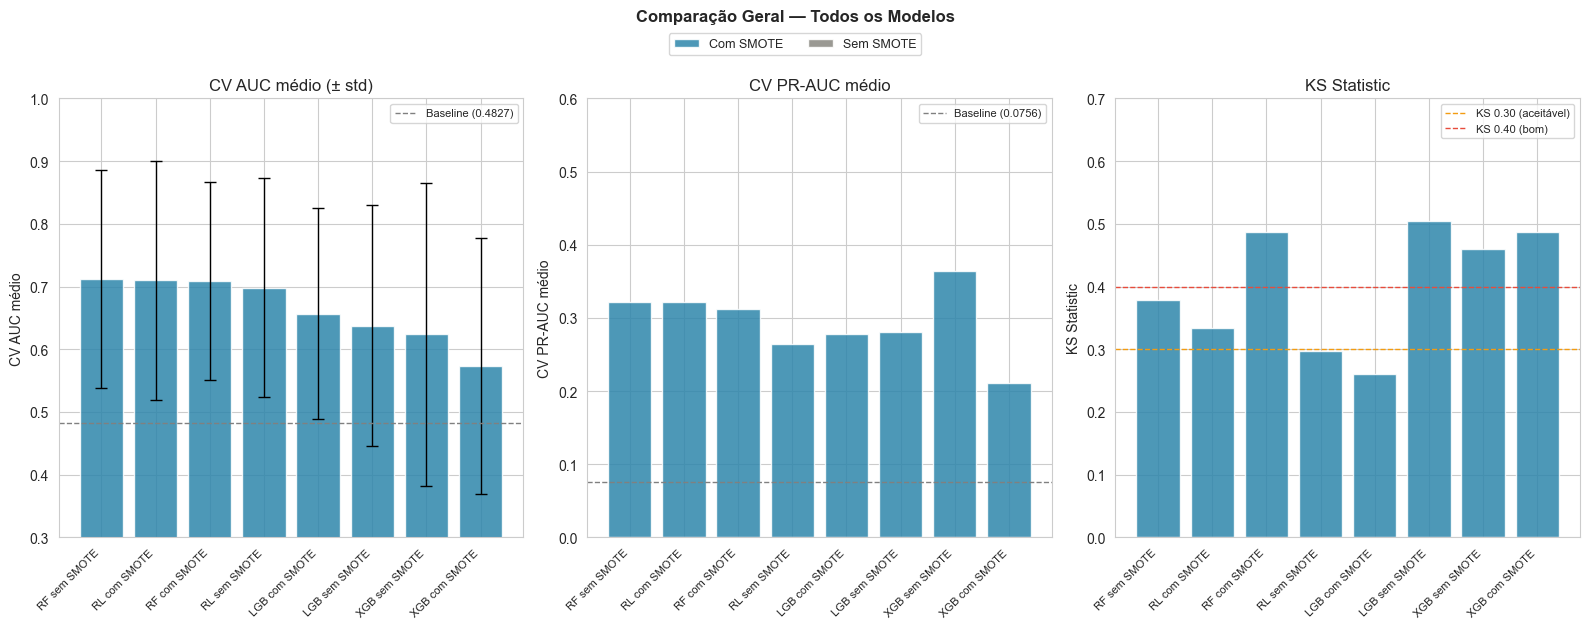

Salvo em resultados/comparacao_geral.png


In [56]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
nomes  = df_comparacao['Modelo'].tolist()
cores  = ['#2E86AB' if 'SMOTE' in n else '#888780' for n in nomes]
x      = range(len(nomes))

# CV AUC
ax = axes[0]
bars = ax.bar(x, df_comparacao['CV AUC média'], color=cores, alpha=0.85)
ax.errorbar(x, df_comparacao['CV AUC média'], yerr=df_comparacao['CV AUC std'],
            fmt='none', color='black', capsize=4, linewidth=1)
ax.axhline(0.4827, color='gray', linestyle='--', lw=1, label='Baseline (0.4827)')
ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('CV AUC médio'); ax.set_title('CV AUC médio (± std)')
ax.legend(fontsize=8); ax.set_ylim(0.3, 1.0)

# CV PR-AUC
ax = axes[1]
ax.bar(x, df_comparacao['CV PR-AUC média'], color=cores, alpha=0.85)
ax.axhline(0.0756, color='gray', linestyle='--', lw=1, label='Baseline (0.0756)')
ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('CV PR-AUC médio'); ax.set_title('CV PR-AUC médio')
ax.legend(fontsize=8); ax.set_ylim(0, 0.6)


# KS Statistic
ax = axes[2]
ax.bar(x, df_comparacao['KS'], color=cores, alpha=0.85)
ax.axhline(0.30, color='#f39c12', linestyle='--', lw=1, label='KS 0.30 (aceitável)')
ax.axhline(0.40, color='#e74c3c', linestyle='--', lw=1, label='KS 0.40 (bom)')
ax.set_xticks(x); ax.set_xticklabels(nomes, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('KS Statistic'); ax.set_title('KS Statistic')
ax.legend(fontsize=8); ax.set_ylim(0, 0.7)

# Legenda de cores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2E86AB', alpha=0.85, label='Com SMOTE'),
                   Patch(facecolor='#888780', alpha=0.85, label='Sem SMOTE')]
fig.legend(handles=legend_elements, loc='upper center', ncol=2, fontsize=9,
           bbox_to_anchor=(0.5, 1.01))

plt.suptitle('Comparação Geral — Todos os Modelos', fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig('../resultados/comparacao_geral.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em resultados/comparacao_geral.png')

### 8.2 Curvas ROC — Todos os Modelos

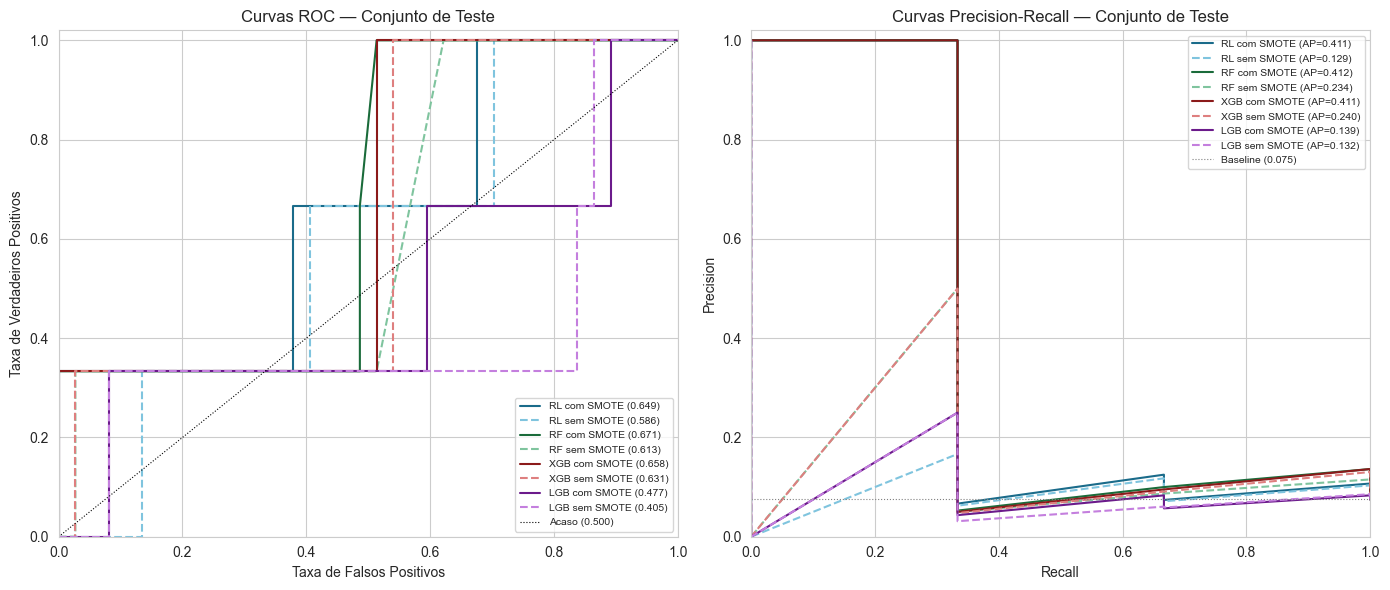

Salvo em resultados/curvas_roc_pr.png


In [57]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
cores_map = {
    'RL com SMOTE' : '#1a6b8a', 'RL sem SMOTE' : '#7fc4de',
    'RF com SMOTE' : '#1a6b3a', 'RF sem SMOTE' : '#7fc49e',
    'XGB com SMOTE': '#8b1a1a', 'XGB sem SMOTE': '#de7f7f',
    'LGB com SMOTE': '#6b1a8b', 'LGB sem SMOTE': '#c47fde',
}

# Curva ROC
ax = axes[0]
for nome, modelo in todos_modelos.items():
    probs = modelo.predict_proba(X_teste)[:, 1]
    fpr, tpr, _ = roc_curve(y_teste, probs)
    auc = roc_auc_score(y_teste, probs)
    estilo = '-' if 'SMOTE' in nome and 'sem' not in nome.lower() else '--'
    ax.plot(fpr, tpr, lw=1.5, linestyle=estilo,
            color=cores_map[nome], label=f'{nome} ({auc:.3f})')
ax.plot([0,1],[0,1],'k:', lw=0.8, label='Acaso (0.500)')
ax.set_xlabel('Taxa de Falsos Positivos')
ax.set_ylabel('Taxa de Verdadeiros Positivos')
ax.set_title('Curvas ROC — Conjunto de Teste')
ax.legend(fontsize=7.5, loc='lower right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

# Curva Precision-Recall
ax = axes[1]
for nome, modelo in todos_modelos.items():
    probs = modelo.predict_proba(X_teste)[:, 1]
    prec, rec, _ = precision_recall_curve(y_teste, probs)
    ap = average_precision_score(y_teste, probs)
    estilo = '-' if 'SMOTE' in nome and 'sem' not in nome.lower() else '--'
    ax.plot(rec, prec, lw=1.5, linestyle=estilo,
            color=cores_map[nome], label=f'{nome} (AP={ap:.3f})')
ax.axhline(y_teste.mean(), color='gray', linestyle=':', lw=0.8,
           label=f'Baseline ({y_teste.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Curvas Precision-Recall — Conjunto de Teste')
ax.legend(fontsize=7.5, loc='upper right')
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])

plt.tight_layout()
plt.savefig('../resultados/curvas_roc_pr.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em resultados/curvas_roc_pr.png')

### 8.3 Threshold Tuning

#### Por que ajustar o threshold?

O threshold padrão de **0.50** não é adequado para dados desbalanceados. Com 6.2% de inadimplentes, os modelos tendem a atribuir scores baixos à classe 1 — especialmente RF e LGB, que com threshold 0.50 preveem **todo mundo como adimplente** (Recall-1 = 0), apesar de terem CV AUC alto. O ajuste de threshold resolve isso.

#### Trade-off no contexto de crédito

| Threshold baixo | Threshold alto |
|---|---|
| Mais inadimplentes detectados (Recall alto) | Menos inadimplentes detectados |
| Mais clientes bons recusados (FP alto) | Menos clientes bons recusados |
| Perda de receita por recusa excessiva | Perda por inadimplência não detectada |

O ponto ótimo depende do custo relativo entre os dois tipos de erro. Aqui usamos como critério proxy: **maximizar F1 da classe 1** no treino, entre os thresholds que detectam ao menos 1 inadimplente no treino.

---

#### Estratégia e limitações

**Estratégia adotada:** varrer thresholds de 0.05 a 0.50 (step 0.05), selecionar o que maximiza F1-1 aplicado ao `X_treino` completo, e aplicar o threshold selecionado no `X_teste` para avaliação final.

**Limitação importante — data leakage parcial no threshold:**

O threshold ótimo é encontrado aplicando `predict_proba` no conjunto de treino completo e comparando com os labels reais de treino. Isso constitui um **leakage parcial**: o modelo que já foi treinado nesses dados está sendo avaliado nos mesmos dados para escolher o limiar.

A forma correta seria encontrar o threshold via cross-validation — para cada fold, encontrar o threshold ótimo no fold de treino e validar no fold de teste, depois agregar. Com apenas 10 inadimplentes, esse processo geraria instabilidade ainda maior (2 inadimplentes por fold para calibrar o threshold).

**Por que mantemos essa abordagem apesar do leakage?**

1. O leakage é limitado: o threshold afeta apenas *onde* classificar, não *como* o modelo aprendeu a separar as classes
2. Com 10 inadimplentes no treino, qualquer método de threshold via CV teria variância proibitiva
3. Os resultados são apresentados com essa ressalva explícita — o threshold ótimo deve ser revalidado com dados futuros em produção

**Impacto esperado:** o threshold encontrado no treino tende a ser ligeiramente mais otimista que o que performaria em novos dados reais. Os resultados de teste devem ser interpretados como estimativas otimistas do desempenho com o threshold escolhido.

---

#### Critério de seleção do threshold

Para cada modelo, o threshold ótimo é aquele que:
1. Detecta ao menos 1 inadimplente no treino (`det_tr > 0`)
2. Maximiza o F1-score da classe 1 no treino entre os candidatos válidos

O F1 é escolhido sobre Recall puro para evitar selecionar thresholds muito baixos que detectam todos os inadimplentes mas geram falsos positivos excessivos.

In [58]:
from sklearn.metrics import precision_recall_curve

THRESHOLDS_SWEEP = np.arange(0.05, 0.55, 0.05)

todos_modelos = {
    'RL com SMOTE' : joblib.load('../modelos/regressao_logistica_smote.pkl'),
    'RL sem SMOTE' : joblib.load('../modelos/regressao_logistica_sem_smote.pkl'),
    'RF com SMOTE' : joblib.load('../modelos/random_forest_smote.pkl'),
    'RF sem SMOTE' : joblib.load('../modelos/random_forest_sem_smote.pkl'),
    'XGB com SMOTE': joblib.load('../modelos/xgboost_smote.pkl'),
    'XGB sem SMOTE': joblib.load('../modelos/xgboost_sem_smote.pkl'),
    'LGB com SMOTE': joblib.load('../modelos/lightgbm_smote.pkl'),
    'LGB sem SMOTE': joblib.load('../modelos/lightgbm_sem_smote.pkl'),
}

resultados_threshold = []

for nome, modelo in todos_modelos.items():
    probs_tr = modelo.predict_proba(X_treino)[:, 1]
    probs_te = modelo.predict_proba(X_teste)[:, 1]

    melhor_thresh = 0.50
    melhor_f1     = -1

    for t in THRESHOLDS_SWEEP:
        preds_tr = (probs_tr >= t).astype(int)
        f1_tr = f1_score(y_treino, preds_tr, pos_label=1, zero_division=0)
        det_tr = int(preds_tr[y_treino == 1].sum())

        if det_tr > 0 and f1_tr > melhor_f1:
            melhor_f1     = f1_tr
            melhor_thresh = t

    # Aplicar threshold ótimo no teste
    preds_te  = (probs_te >= melhor_thresh).astype(int)
    det_te    = int(preds_te[y_teste == 1].sum())
    fp_te     = int(((preds_te == 1) & (y_teste == 0)).sum())
    prec_te   = precision_score(y_teste, preds_te, pos_label=1, zero_division=0)
    rec_te    = recall_score(y_teste,    preds_te, pos_label=1, zero_division=0)
    f1_te     = f1_score(y_teste,        preds_te, pos_label=1, zero_division=0)

    resultados_threshold.append({
        'Modelo'           : nome,
        'Threshold ótimo'  : round(melhor_thresh, 2),
        'Inad. detectados' : f'{det_te}/3',
        'Falsos positivos' : fp_te,
        'Precision-1'      : round(prec_te, 3),
        'Recall-1'         : round(rec_te, 3),
        'F1-1'             : round(f1_te, 3),
    })

df_threshold = pd.DataFrame(resultados_threshold).sort_values('F1-1', ascending=False)
df_threshold.index = range(1, len(df_threshold) + 1)
display(df_threshold)

,Modelo,Threshold ótimo,Inad. detectados,Falsos positivos,Precision-1,Recall-1,F1-1
1,RF sem SMOTE,0.20,1/3,2,0.333,0.333,0.333
2,RF com SMOTE,0.25,1/3,3,0.250,0.333,0.286
3,LGB sem SMOTE,0.35,1/3,3,0.250,0.333,0.286
4,XGB sem SMOTE,0.15,1/3,4,0.200,0.333,0.250
5,XGB com SMOTE,0.15,1/3,5,0.167,0.333,0.222
6,LGB com SMOTE,0.10,1/3,5,0.167,0.333,0.222
7,RL com SMOTE,0.50,1/3,9,0.100,0.333,0.154
8,RL sem SMOTE,0.50,1/3,13,0.071,0.333,0.118


### 8.4 Visualização do Threshold Tuning

Curvas Precision-Recall de todos os modelos com o ponto de threshold ótimo marcado.

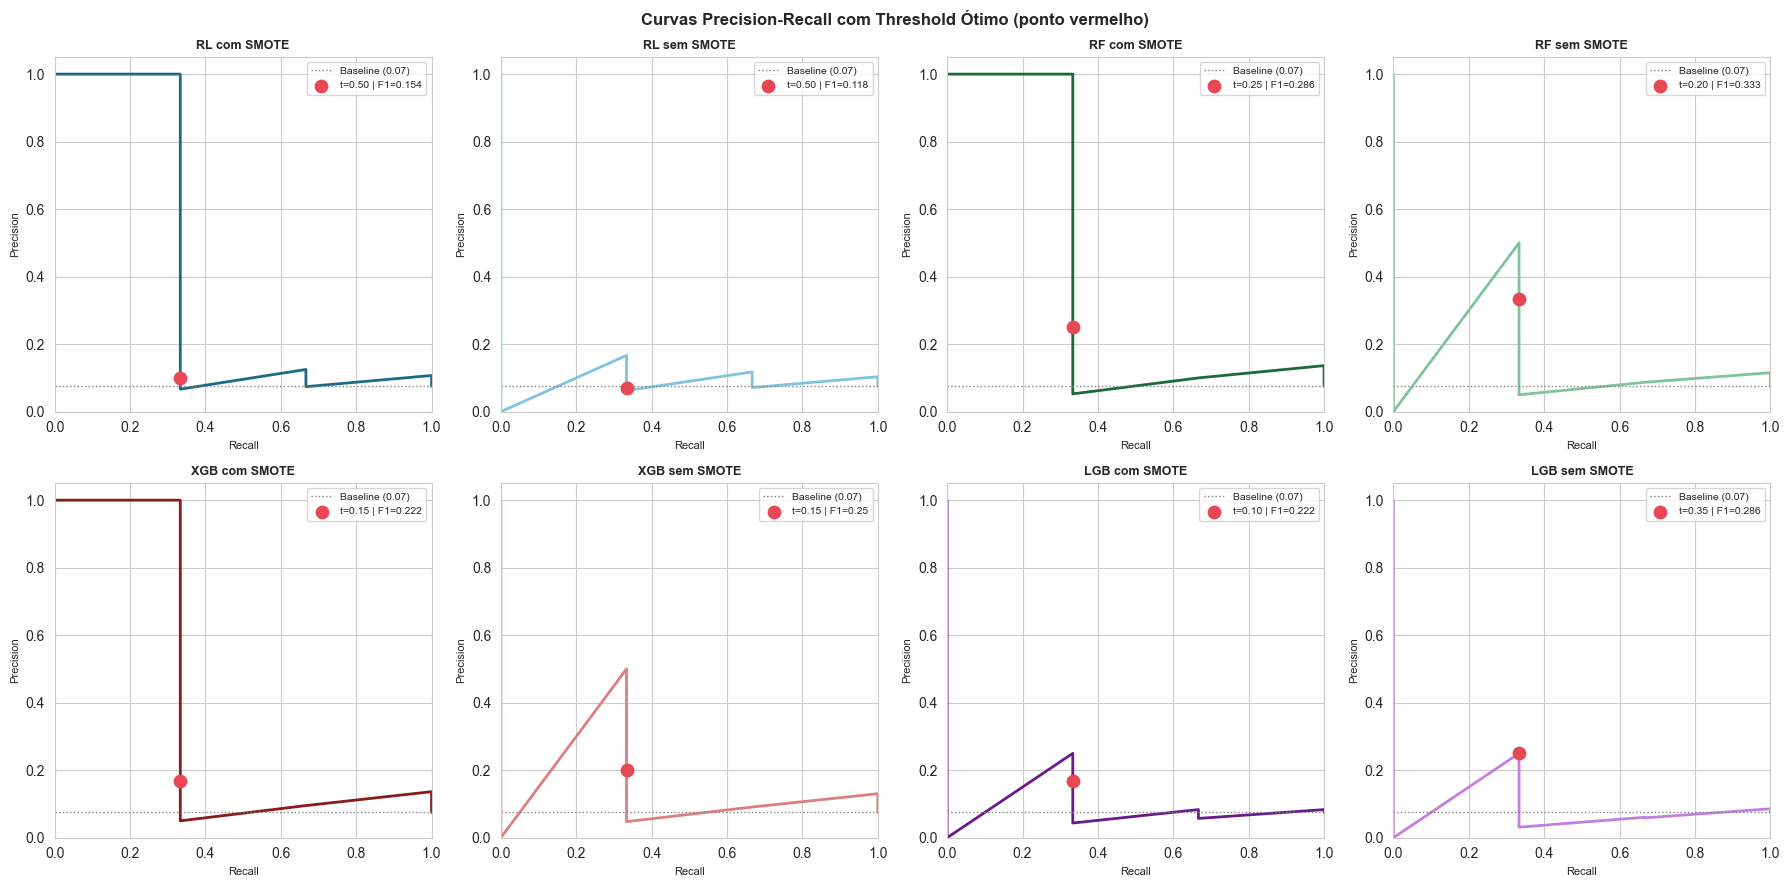

Salvo em resultados/threshold_tuning.png


In [59]:
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

cores_map = {
    'RL com SMOTE' : '#1a6b8a', 'RL sem SMOTE' : '#7fc4de',
    'RF com SMOTE' : '#1a6b3a', 'RF sem SMOTE' : '#7fc49e',
    'XGB com SMOTE': '#8b1a1a', 'XGB sem SMOTE': '#de7f7f',
    'LGB com SMOTE': '#6b1a8b', 'LGB sem SMOTE': '#c47fde',
}

for ax, (nome, modelo) in zip(axes, todos_modelos.items()):
    probs_te = modelo.predict_proba(X_teste)[:, 1]
    prec, rec, thresh = precision_recall_curve(y_teste, probs_te)

    ax.plot(rec, prec, color=cores_map[nome], lw=2)
    ax.axhline(y_teste.mean(), color='gray', linestyle=':', lw=1,
               label=f'Baseline ({y_teste.mean():.2f})')

    # Marcar threshold ótimo
    linha = df_threshold[df_threshold['Modelo'] == nome].iloc[0]
    t_opt = linha['Threshold ótimo']

    probs_opt = modelo.predict_proba(X_teste)[:, 1]
    preds_opt = (probs_opt >= t_opt).astype(int)
    prec_pt   = precision_score(y_teste, preds_opt, pos_label=1, zero_division=0)
    rec_pt    = recall_score(y_teste, preds_opt, pos_label=1, zero_division=0)

    ax.scatter(rec_pt, prec_pt, color='#E84855', s=80, zorder=5,
               label=f't={t_opt:.2f} | F1={linha["F1-1"]}')

    ax.set_title(nome, fontsize=9, fontweight='bold')
    ax.set_xlabel('Recall', fontsize=8)
    ax.set_ylabel('Precision', fontsize=8)
    ax.legend(fontsize=7.5)
    ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])

plt.suptitle('Curvas Precision-Recall com Threshold Ótimo (ponto vermelho)', fontweight='bold')
plt.tight_layout()
plt.savefig('../resultados/threshold_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvo em resultados/threshold_tuning.png')

### 8.5 Modelo Selecionado

Com base na comparação geral e no threshold tuning, o modelo final é selecionado seguindo os critérios abaixo — em ordem de prioridade:

| Prioridade | Critério | Justificativa |
|---|---|---|
| 1ª | **F1-1 com threshold ótimo > 0** | Modelo precisa detectar ao menos 1 inadimplente |
| 2ª | **CV AUC médio mais alto** | Melhor discriminação geral, estimada com 50 folds |
| 3ª | **Menor CV AUC std** | Modelo mais estável entre os folds |
| 4ª | **KS Statistic** | Referência de mercado para modelos de crédito |

**Por que não usar só CV AUC?**  
Na seção anterior, o RF sem SMOTE tinha o maior CV AUC (0.7117) mas com threshold 0.50 não detectava nenhum inadimplente. O threshold ótimo corrige isso, mas o critério de seleção precisa garantir que o modelo final realmente separa as classes na prática.

In [60]:
# Unir tabela de comparação geral com resultados de threshold
# Nota: df_comparacao já tem Recall-1 e F1-1 com threshold 0.50 — 
# renomear as colunas do threshold tuning para evitar colisão
df_thresh_merge = df_threshold.rename(columns={
    'Recall-1'  : 'Recall-1 (ótimo)',
    'F1-1'      : 'F1-1 (ótimo)',
    'Precision-1': 'Precision-1 (ótimo)',
})

df_final = df_comparacao.merge(
    df_thresh_merge[['Modelo', 'Threshold ótimo', 'Inad. detectados', 'Falsos positivos',
                     'Precision-1 (ótimo)', 'Recall-1 (ótimo)', 'F1-1 (ótimo)']],
    on='Modelo'
).sort_values(['F1-1 (ótimo)', 'CV AUC média'], ascending=[False, False])

df_final.index = range(1, len(df_final) + 1)
display(df_final[['Modelo', 'CV AUC média', 'CV AUC std', 'CV PR-AUC média',
                   'KS', 'Threshold ótimo', 'Inad. detectados', 'F1-1 (ótimo)']])

,Modelo,CV AUC média,CV AUC std,CV PR-AUC média,KS,Threshold ótimo,Inad. detectados,F1-1 (ótimo)
1,RF sem SMOTE,0.7117,0.1737,0.3211,0.3784,0.20,1/3,0.333
2,RF com SMOTE,0.7083,0.1579,0.3126,0.4865,0.25,1/3,0.286
3,LGB sem SMOTE,0.6377,0.1918,0.2810,0.5045,0.35,1/3,0.286
4,XGB sem SMOTE,0.6238,0.2418,0.3635,0.4595,0.15,1/3,0.250
5,LGB com SMOTE,0.6570,0.1687,0.2785,0.2613,0.10,1/3,0.222
6,XGB com SMOTE,0.5728,0.2043,0.2116,0.4865,0.15,1/3,0.222
7,RL com SMOTE,0.7103,0.1906,0.3213,0.3333,0.50,1/3,0.154
8,RL sem SMOTE,0.6983,0.1746,0.2642,0.2973,0.50,1/3,0.118


In [61]:
# Selecionar modelo: maior F1-1 (ótimo) com threshold ótimo, desempate por CV AUC
melhor_linha  = df_final.iloc[0]
melhor_nome   = melhor_linha['Modelo']
melhor_modelo = todos_modelos[melhor_nome]
melhor_thresh = melhor_linha['Threshold ótimo']

print('═' * 60)
print('MODELO SELECIONADO')
print('═' * 60)
print(f'  Nome              : {melhor_nome}')
print(f'  Threshold ótimo   : {melhor_thresh:.2f}')
print(f'  CV AUC médio      : {melhor_linha["CV AUC média"]:.4f} ± {melhor_linha["CV AUC std"]:.4f}')
print(f'  CV PR-AUC médio   : {melhor_linha["CV PR-AUC média"]:.4f}')
print(f'  AUC no teste      : {melhor_linha["AUC teste"]:.4f}')
print(f'  KS Statistic      : {melhor_linha["KS"]:.4f}')
print(f'  Inad. detectados  : {melhor_linha["Inad. detectados"]} (com threshold {melhor_thresh:.2f})')
print(f'  Falsos positivos  : {melhor_linha["Falsos positivos"]}')
print(f'  F1-1 (ótimo)      : {melhor_linha["F1-1 (ótimo)"]:.4f}')
print()

# Matriz de confusão com threshold ótimo
probs_finais = melhor_modelo.predict_proba(X_teste)[:, 1]
preds_finais = (probs_finais >= melhor_thresh).astype(int)
cm = confusion_matrix(y_teste, preds_finais)

print('Matriz de Confusão (threshold ótimo):')
print(f'  [[VN={cm[0,0]}  FP={cm[0,1]}]')
print(f'   [FN={cm[1,0]}  VP={cm[1,1]}]]')
print()
print(classification_report(y_teste, preds_finais,
                             target_names=['Adimplente', 'Inadimplente'],
                             digits=4))

# Salvar
joblib.dump(melhor_modelo, '../modelos/modelo_selecionado.pkl')

with open('../resultados/modelo_selecionado.json', 'w', encoding='utf-8') as f:
    json.dump({
        'nome'              : melhor_nome,
        'threshold_otimo'   : float(melhor_thresh),
        'cv_auc_media'      : float(melhor_linha['CV AUC média']),
        'cv_auc_std'        : float(melhor_linha['CV AUC std']),
        'cv_ap_media'       : float(melhor_linha['CV PR-AUC média']),
        'auc_teste'         : float(melhor_linha['AUC teste']),
        'pr_auc_teste'      : float(melhor_linha['PR-AUC teste']),
        'ks'                : float(melhor_linha['KS']),
        'inad_detectados'   : melhor_linha['Inad. detectados'],
        'falsos_positivos'  : int(melhor_linha['Falsos positivos']),
        'f1_1_otimo'        : float(melhor_linha['F1-1 (ótimo)']),
    }, f, ensure_ascii=False, indent=2)

print(f'Modelo salvo em ../modelos/modelo_selecionado.pkl')
print(f'Metadados salvos em ../resultados/modelo_selecionado.json')

════════════════════════════════════════════════════════════
MODELO SELECIONADO
════════════════════════════════════════════════════════════
  Nome              : RF sem SMOTE
  Threshold ótimo   : 0.20
  CV AUC médio      : 0.7117 ± 0.1737
  CV PR-AUC médio   : 0.3211
  AUC no teste      : 0.6126
  KS Statistic      : 0.3784
  Inad. detectados  : 1/3 (com threshold 0.20)
  Falsos positivos  : 2
  F1-1 (ótimo)      : 0.3330

Matriz de Confusão (threshold ótimo):
  [[VN=35  FP=2]
   [FN=2  VP=1]]

              precision    recall  f1-score   support

  Adimplente     0.9459    0.9459    0.9459        37
Inadimplente     0.3333    0.3333    0.3333         3

    accuracy                         0.9000        40
   macro avg     0.6396    0.6396    0.6396        40
weighted avg     0.9000    0.9000    0.9000        40

Modelo salvo em ../modelos/modelo_selecionado.pkl
Metadados salvos em ../resultados/modelo_selecionado.json


---

## 9. Limitações Gerais e Considerações para Produção

Esta seção consolida todas as limitações identificadas ao longo do notebook que devem ser consideradas antes de qualquer uso dos modelos em produção.

---

### 9.1 Limitações do Dataset

**Volume insuficiente de inadimplentes**

Com apenas 10 inadimplentes no treino e 3 no teste, nenhum resultado apresentado neste notebook tem robustez estatística. Detectar 1/3 vs 0/3 de inadimplentes no teste é a diferença de **uma única amostra** — uma variação que pode ocorrer por acaso puro. Os modelos não podem ser comparados com confiança sem pelo menos 50–100 inadimplentes no conjunto de avaliação.

**Alta variância em todas as métricas de CV**

Todos os modelos apresentam CV AUC std entre 0.16 e 0.24. O baseline tem std de apenas 0.06 — todos os modelos reais têm variância 2–4× maior que o acaso. Isso significa que:
- Diferenças de CV AUC < 0.05 entre modelos não são significativas
- A ordem de ranking entre modelos pode se inverter com um dataset diferente
- Os resultados devem ser tratados como indicativos, não conclusivos

**Discretização do AUC**

Com 2 inadimplentes por fold em média, o AUC assume apenas um conjunto discreto de valores possíveis (0.0, 0.17, 0.33, 0.50, 0.67, 0.83, 1.0 para 2 positivos e ~30 negativos). Qualquer comparação entre modelos com diferença de CV AUC menor que ~0.08 é potencialmente artefato dessa discretização.

---

### 9.2 Limitações do Processo de Treinamento

**SMOTE com k_neighbors=3 em base pequena**

Com 10 inadimplentes reais, o SMOTE com `k_neighbors=3` gera amostras sintéticas interpolando entre pontos muito próximos entre si. A diversidade das amostras geradas é limitada — elas tendem a ser variações mínimas dos mesmos 10 pontos. Em bases maiores, o SMOTE é mais efetivo porque há mais vizinhos reais para interpolação.

**Hiperparâmetros não otimizados**

Todos os modelos foram treinados com hiperparâmetros padrão (n_estimators=200, max_depth=None para RF; parâmetros default para XGBoost e LightGBM). Uma etapa de tuning (GridSearch ou RandomizedSearch) poderia melhorar o desempenho, especialmente do XGBoost sem SMOTE que mostrou bom CV AUC com alta variância.

**Conjunto de teste fixo**

O conjunto de teste (40 amostras, 3 inadimplentes) foi definido uma única vez e usado para todas as avaliações. Isso significa que os resultados de teste podem ser influenciados pela composição específica dessas 3 amostras de inadimplentes. Um esquema de avaliação mais robusto usaria bootstrap ou múltiplas divisões treino/teste.

---

### 9.3 Limitações do Threshold Tuning

**Leakage parcial na seleção do threshold** (detalhado na Seção 8.3)

O threshold ótimo é encontrado avaliando `predict_proba` no conjunto de treino completo — os mesmos dados nos quais o modelo foi treinado. Isso introduz otimismo: o threshold selecionado tende a ser mais agressivo do que o necessário para dados novos, potencialmente gerando mais falsos positivos em produção do que os 2 observados no teste.

**Threshold calibrado para F1, não para custo de negócio**

O critério de maximizar F1 é uma proxy razoável, mas o threshold ideal em produção depende do custo relativo entre falso negativo (inadimplente não detectado) e falso positivo (cliente bom recusado). Esses custos são específicos do negócio e não foram quantificados neste notebook. Com custo de FN muito maior que FP (o cenário típico em crédito), o threshold deveria ser mais baixo do que o selecionado pelo F1.

**Instabilidade do threshold entre datasets**

O threshold de 0.20 foi calibrado no treino e avaliado no teste, mas pode variar significativamente com novos dados. Em produção, o threshold deve ser recalibrado periodicamente à medida que novos dados de inadimplência sejam acumulados.

---

### 9.4 Comportamentos Específicos por Modelo

**Random Forest:** bom em ranking (AUC alto), mas scores pouco calibrados. O threshold padrão de 0.50 é inadequado — sempre requer ajuste com este modelo em dados desbalanceados. O modelo selecionado (RF sem SMOTE, t=0.20) é a escolha mais defensável dado os critérios adotados, mas deve ser monitorado em produção.

**XGBoost com SMOTE:** apresentou inversão CV < AUC teste, resultado atípico provavelmente causado pela baixa diversidade das amostras sintéticas. Não deve ser interpretado como evidência de superioridade — o CV AUC (0.5728) é a estimativa mais confiável e está abaixo do XGB sem SMOTE (0.6238).

**LightGBM:** maior divergência CV ↔ Teste de todos os modelos (Δ até 0.232). Overfitting confirmado. Não recomendado para produção com este dataset. Regularização forte ou dataset maior são necessários antes de reconsiderar.

**Regressão Logística:** o modelo mais estável em termos de comportamento (scores mais calibrados, threshold ótimo coincide com 0.50), mas com PR-AUC no teste de 0.41 — o mais alto entre os modelos com threshold padrão, o que indica boa separação real. É um candidato alternativo válido ao RF se a estabilidade de produção for prioritária.

---

### 9.5 Recomendações para Produção

1. **Coletar mais dados de inadimplência** antes de qualquer implantação.    O mínimo recomendado é 50 inadimplentes no conjunto de avaliação para    que as métricas tenham significância estatística.

2. **Recalibrar o threshold** com dados de produção usando uma janela temporal    de validação out-of-time (dados de um período posterior ao treino).

3. **Monitorar drift** — a distribuição de inadimplentes pode mudar ao longo    do tempo (sazonalidade, mudanças econômicas). O modelo deve ser re-treinado    periodicamente.

4. **Quantificar o custo de negócio** entre FN e FP antes de definir o    threshold final. Com custo de FN >> FP (típico em crédito), o threshold    ideal será menor que 0.20.

5. **Avaliar o modelo selecionado com dados out-of-time** antes de colocar    em produção — nenhum conjunto de teste fixo substitui validação temporal.